# Lorentzian sweep data

Load the two `data/lorentzian_1` bundles and plot the no-echo and echo Lorentzian sweeps side by side.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from bundle_utils import amp_prefactor_to_rabi_amp_mhz, extract_qubit_variables
from presentation_style import polish_axes, use_presentation_style

use_presentation_style()

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "lorentzian_1"
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

bundle_paths = sorted(DATA_DIR.glob("echo_lorentzian*_data_bundle.npz"))
if not bundle_paths:
    raise FileNotFoundError(f"No echo_lorentzian bundles found in {DATA_DIR}")

sweeps = []
for path in bundle_paths:
    sweep_data = extract_qubit_variables(path)
    echo = bool(sweep_data.parameters.get("echo", False))
    amp_prefactor = np.asarray(sweep_data.amp_prefactor, dtype=float)
    if sweep_data.rabi_amp_mhz is None:
        y_axis = amp_prefactor
        y_label = "Amplitude prefactor"
    else:
        y_axis = np.asarray(sweep_data.rabi_amp_mhz, dtype=float)
        y_label = "Rabi amplitude (MHz)"
    sweeps.append(
        {
            "path": path,
            "data": sweep_data,
            "echo": echo,
            "label": "Echo" if echo else "No echo",
            "detuning_mhz": sweep_data.detuning_hz / 1e6,
            "amp_prefactor": amp_prefactor,
            "y_axis": y_axis,
            "y_label": y_label,
        }
    )

sweeps = sorted(sweeps, key=lambda sweep: sweep["echo"])
if len(sweeps) != 2:
    raise ValueError(f"Expected 2 bundles in {DATA_DIR}, found {len(sweeps)}")

# Keep these names available for the optional single-sweep cells below.
data = sweeps[0]["data"]
detuning_mhz = sweeps[0]["detuning_mhz"]
amp_prefactor = sweeps[0]["amp_prefactor"]
y_axis = sweeps[0]["y_axis"]
y_label = sweeps[0]["y_label"]

print("Available Lorentzian bundles:")
for index, sweep in enumerate(sweeps):
    path = sweep["path"]
    print(f"[{index}] {sweep['label']}: {path.relative_to(PROJECT_DIR)}")

print()
for sweep in sweeps:
    sweep_data = sweep["data"]
    print(f"{sweep['label']}:")
    print(f"  Qubit: {sweep_data.qubit_name}")
    print(f"  Timestamp: {sweep_data.metadata.get('timestamp', 'unknown')}")
    print(f"  State shape: {sweep_data.result.shape} = detuning x amplitude")
    print(f"  Detuning range: {sweep['detuning_mhz'].min():g} to {sweep['detuning_mhz'].max():g} MHz")
    print(f"  Amplitude prefactor range: {sweep['amp_prefactor'].min():g} to {sweep['amp_prefactor'].max():g}")
    if sweep_data.rabi_amp_mhz is not None:
        print(f"  Rabi amplitude range: {sweep['y_axis'].min():g} to {sweep['y_axis'].max():g} MHz")
    print(f"  State range: {np.nanmin(sweep_data.result):.4f} to {np.nanmax(sweep_data.result):.4f}")

Available Lorentzian bundles:
[0] No echo: data\lorentzian_1\echo_lorentzian_10-40-57-854895_data_bundle.npz
[1] Echo: data\lorentzian_1\echo_lorentzian_10-40-05-277866_data_bundle.npz

No echo:
  Qubit: q1
  Timestamp: 2026-06-30T10:40:57.854895+03:00
  State shape: (101, 100) = detuning x amplitude
  Detuning range: -0.5 to 0.5 MHz
  Amplitude prefactor range: 0 to 0.99
  Rabi amplitude range: 0 to 76.5806 MHz
  State range: 0.0000 to 0.8500
Echo:
  Qubit: q1
  Timestamp: 2026-06-30T10:40:05.277866+03:00
  State shape: (101, 100) = detuning x amplitude
  Detuning range: -0.5 to 0.5 MHz
  Amplitude prefactor range: 0 to 0.99
  Rabi amplitude range: 0 to 76.5806 MHz
  State range: 0.0000 to 0.9750


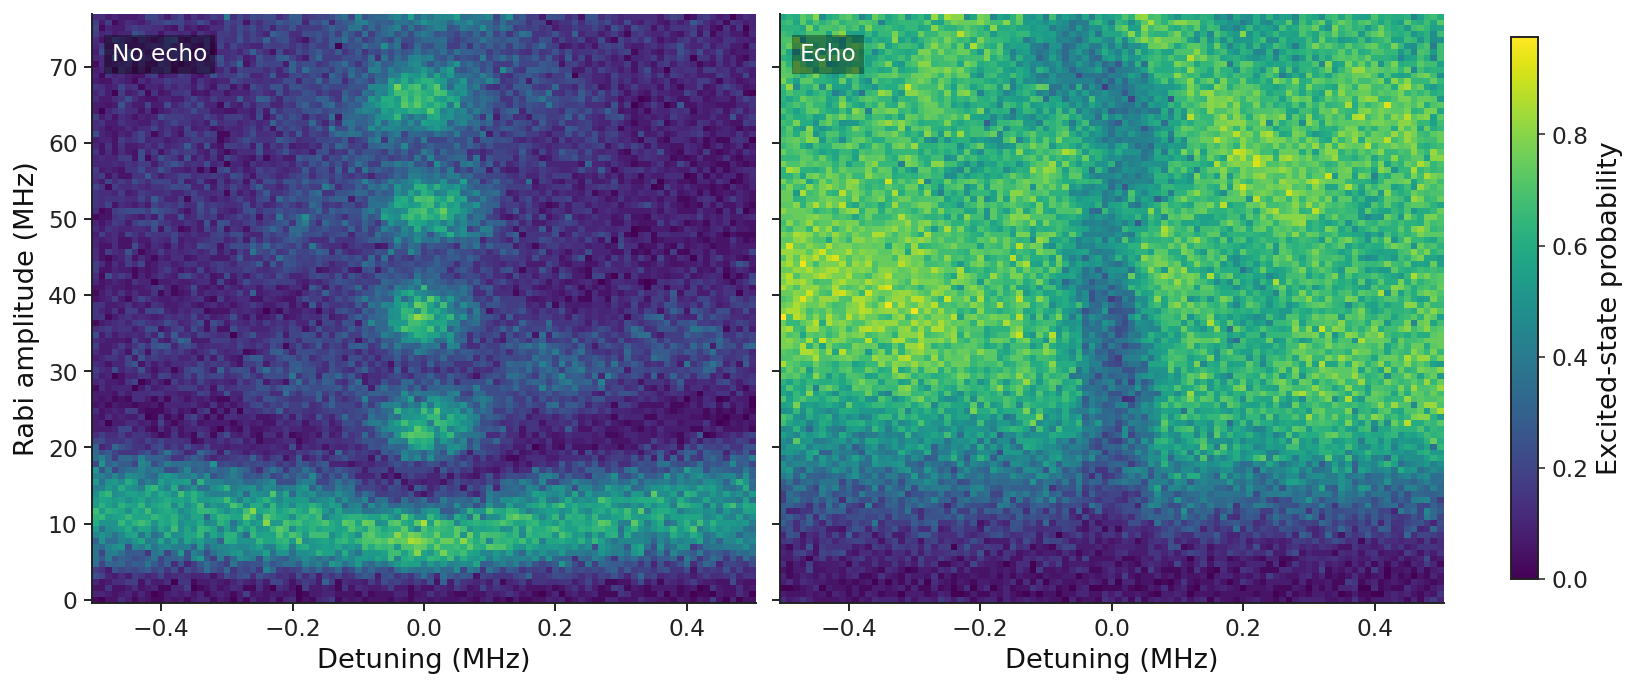

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_data_no_echo_vs_echo_q1.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_data_no_echo_vs_echo_q1.pdf


In [11]:
vmin = min(float(np.nanmin(sweep["data"].result)) for sweep in sweeps)
vmax = max(float(np.nanmax(sweep["data"].result)) for sweep in sweeps)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.8), constrained_layout=True, sharey=True)

mesh = None
for ax, sweep in zip(axes, sweeps):
    mesh = ax.pcolormesh(
        sweep["detuning_mhz"],
        sweep["y_axis"],
        sweep["data"].result.T,
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.text(
        0.03,
        0.95,
        sweep["label"],
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=12,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none", "pad": 4},
    )
    # ax.axvline(0, color="white", linewidth=1.0, linestyle="--", alpha=0.8)
    ax.set_xlabel(r"Drive detuning $(f_d-f_{01})$ (MHz)")
    polish_axes(ax)

axes[0].set_ylabel(sweeps[0]["y_label"])
colorbar = fig.colorbar(mesh, ax=axes, shrink=0.92)
colorbar.set_label("Excited-state probability")

figure_stem = FIGURES_DIR / f"03_lorentzian_data_no_echo_vs_echo_{sweeps[0]['data'].qubit_name}"
png_path = figure_stem.with_suffix(".png")
pdf_path = figure_stem.with_suffix(".pdf")
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")

Broad Lorentzian bundles:
[0] No echo: data\loretzaian broad_1\echo_lorentzian_10-48-38-032784_data_bundle.npz
[1] Echo: data\loretzaian broad_1\echo_lorentzian_10-49-56-562210_data_bundle.npz

No echo broad:
  Qubit: q1
  Timestamp: 2026-06-30T10:48:38.032784+03:00
  State shape: (401, 100) = detuning x amplitude
  Detuning range: -200 to 200 MHz
  Amplitude prefactor range: 0 to 0.99
  Rabi amplitude range: 0 to 76.5806 MHz
  State range: 0.0000 to 1.0000
Echo broad:
  Qubit: q1
  Timestamp: 2026-06-30T10:49:56.562210+03:00
  State shape: (401, 100) = detuning x amplitude
  Detuning range: -200 to 200 MHz
  Amplitude prefactor range: 0 to 0.99
  Rabi amplitude range: 0 to 76.5806 MHz
  State range: 0.0000 to 0.9500


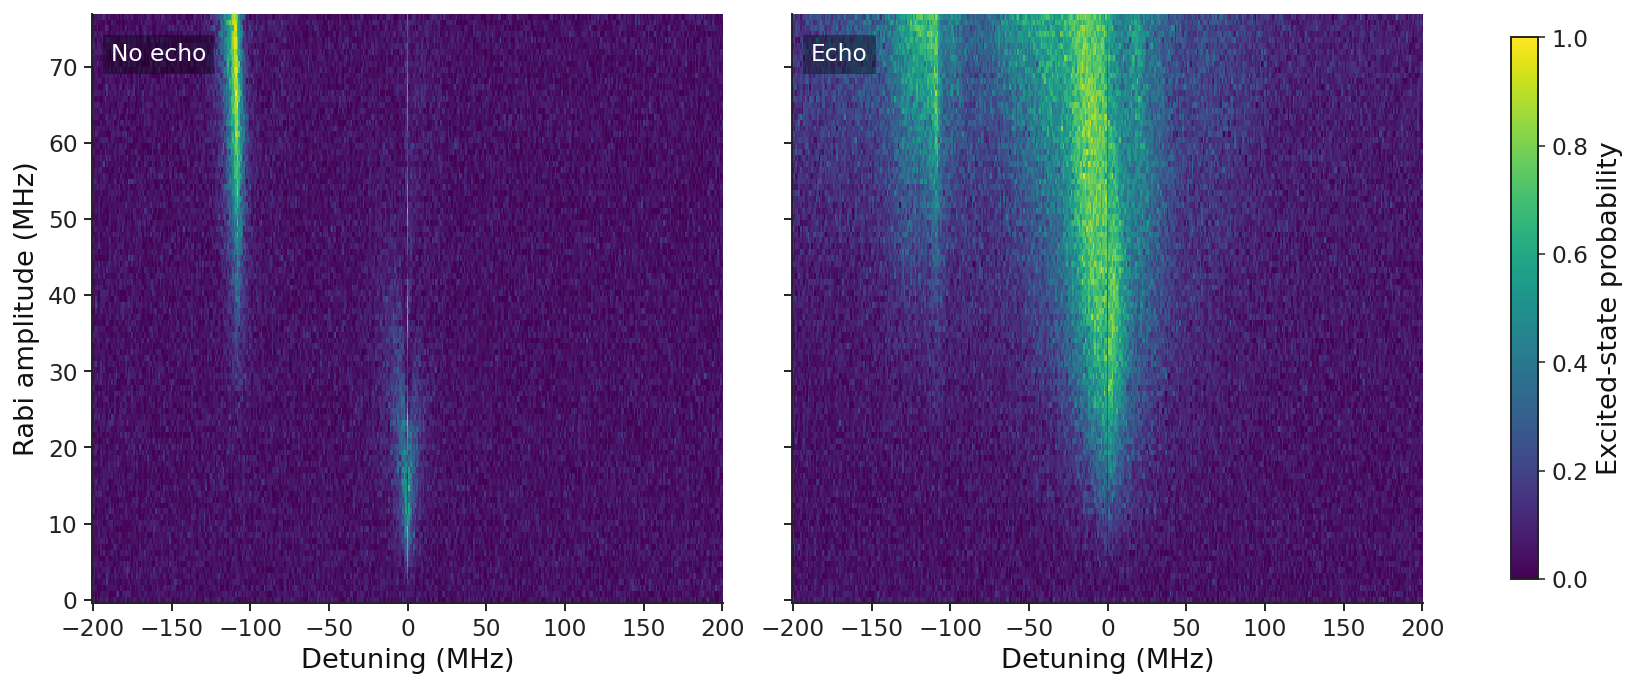

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_broad_no_echo_vs_echo_q1.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_broad_no_echo_vs_echo_q1.pdf


In [10]:
BROAD_DATA_DIR = PROJECT_DIR / "data" / "loretzaian broad_1"
broad_bundle_paths = sorted(BROAD_DATA_DIR.glob("echo_lorentzian*_data_bundle.npz"))
if len(broad_bundle_paths) != 2:
    raise ValueError(f"Expected 2 bundles in {BROAD_DATA_DIR}, found {len(broad_bundle_paths)}")

broad_sweeps = []
for path in broad_bundle_paths:
    sweep_data = extract_qubit_variables(path)
    echo = bool(sweep_data.parameters.get("echo", False))
    amp_prefactor = np.asarray(sweep_data.amp_prefactor, dtype=float)
    if sweep_data.rabi_amp_mhz is None:
        y_axis = amp_prefactor
        y_label = "Amplitude prefactor"
    else:
        y_axis = np.asarray(sweep_data.rabi_amp_mhz, dtype=float)
        y_label = "Rabi amplitude (MHz)"
    broad_sweeps.append(
        {
            "path": path,
            "data": sweep_data,
            "echo": echo,
            "label": "Echo" if echo else "No echo",
            "detuning_mhz": sweep_data.detuning_hz / 1e6,
            "amp_prefactor": amp_prefactor,
            "y_axis": y_axis,
            "y_label": y_label,
        }
    )

broad_sweeps = sorted(broad_sweeps, key=lambda sweep: sweep["echo"])

print("Broad Lorentzian bundles:")
for index, sweep in enumerate(broad_sweeps):
    path = sweep["path"]
    print(f"[{index}] {sweep['label']}: {path.relative_to(PROJECT_DIR)}")

print()
for sweep in broad_sweeps:
    sweep_data = sweep["data"]
    print(f"{sweep['label']} broad:")
    print(f"  Qubit: {sweep_data.qubit_name}")
    print(f"  Timestamp: {sweep_data.metadata.get('timestamp', 'unknown')}")
    print(f"  State shape: {sweep_data.result.shape} = detuning x amplitude")
    print(f"  Detuning range: {sweep['detuning_mhz'].min():g} to {sweep['detuning_mhz'].max():g} MHz")
    print(f"  Amplitude prefactor range: {sweep['amp_prefactor'].min():g} to {sweep['amp_prefactor'].max():g}")
    if sweep_data.rabi_amp_mhz is not None:
        print(f"  Rabi amplitude range: {sweep['y_axis'].min():g} to {sweep['y_axis'].max():g} MHz")
    print(f"  State range: {np.nanmin(sweep_data.result):.4f} to {np.nanmax(sweep_data.result):.4f}")

vmin = min(float(np.nanmin(sweep["data"].result)) for sweep in broad_sweeps)
vmax = max(float(np.nanmax(sweep["data"].result)) for sweep in broad_sweeps)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.8), constrained_layout=True, sharey=True)

mesh = None
for ax, sweep in zip(axes, broad_sweeps):
    mesh = ax.pcolormesh(
        sweep["detuning_mhz"],
        sweep["y_axis"],
        sweep["data"].result.T,
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.text(
        0.03,
        0.95,
        sweep["label"],
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=12,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none", "pad": 4},
    )
    # ax.axvline(0, color="white", linewidth=1.0, linestyle="--", alpha=0.8)
    ax.set_xlabel(r"Drive detuning $(f_d-f_{01})$ (MHz)")
    polish_axes(ax)

axes[0].set_ylabel(broad_sweeps[0]["y_label"])
colorbar = fig.colorbar(mesh, ax=axes, shrink=0.92)
colorbar.set_label("Excited-state probability")

figure_stem = FIGURES_DIR / f"03_lorentzian_broad_no_echo_vs_echo_{broad_sweeps[0]['data'].qubit_name}"
png_path = figure_stem.with_suffix(".png")
pdf_path = figure_stem.with_suffix(".pdf")
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")

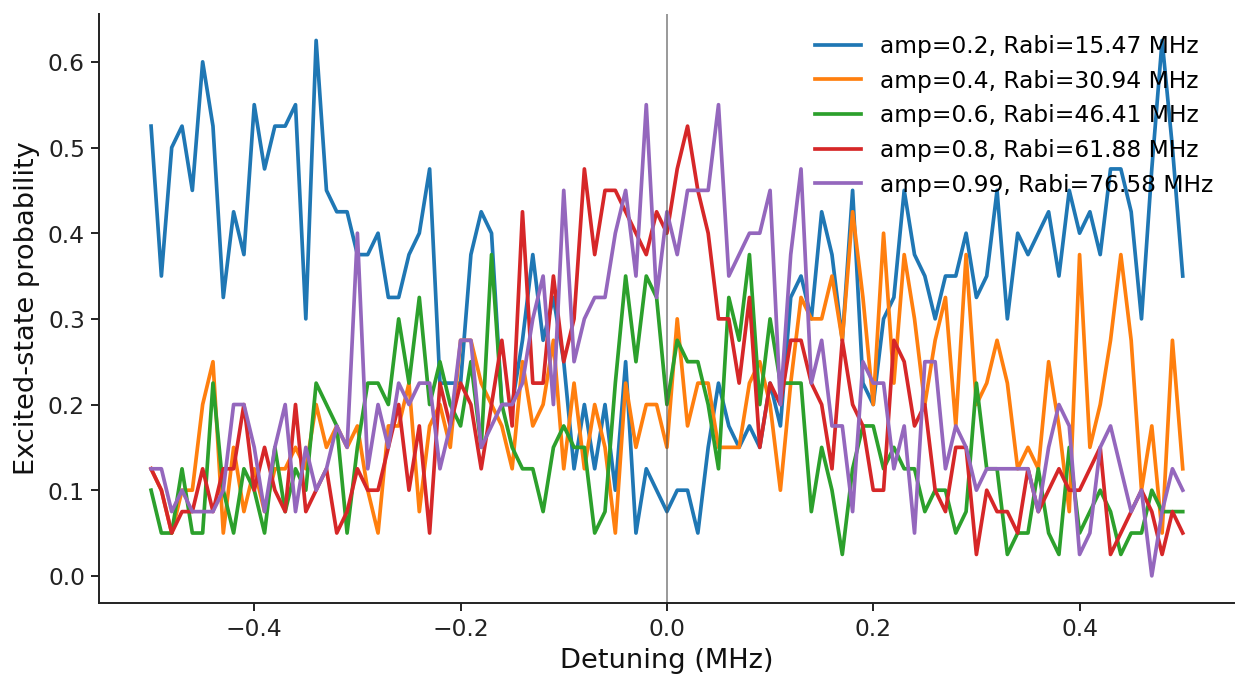

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_data_slices_q1.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_data_slices_q1.pdf


In [8]:
target_amp_prefactors = [0.2, 0.4, 0.6, 0.8, 1.0]
slice_indices = sorted({int(np.argmin(np.abs(amp_prefactor - target))) for target in target_amp_prefactors})

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)

for index in slice_indices:
    if data.rabi_amp_mhz is None:
        label = f"amp={amp_prefactor[index]:.3g}"
    else:
        label = f"amp={amp_prefactor[index]:.3g}, Rabi={data.rabi_amp_mhz[index]:.2f} MHz"
    ax.plot(detuning_mhz, data.result[:, index], linewidth=1.9, label=label)

ax.axvline(0, color="#555555", linewidth=1.0, alpha=0.6)
ax.set_xlabel(r"Drive detuning $(f_d-f_{01})$ (MHz)")
ax.set_ylabel("Excited-state probability")
ax.legend(loc="best")
polish_axes(ax)

figure_stem = FIGURES_DIR / f"03_lorentzian_data_slices_{data.qubit_name}"
png_path = figure_stem.with_suffix(".png")
pdf_path = figure_stem.with_suffix(".pdf")
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")

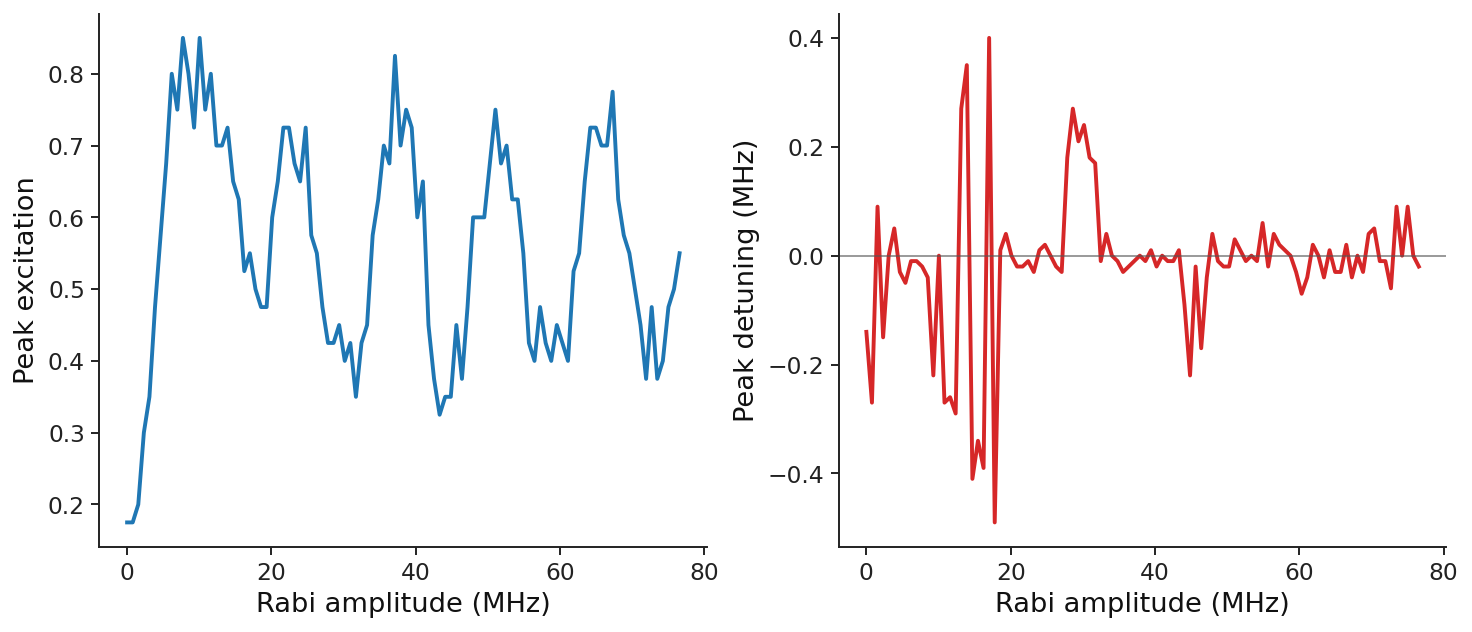

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_data_peak_summary_q1.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\03_lorentzian_data_peak_summary_q1.pdf


In [9]:
peak_by_amp = np.nanmax(data.result, axis=0)
peak_detuning_mhz = detuning_mhz[np.nanargmax(data.result, axis=0)]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4), constrained_layout=True)

axes[0].plot(y_axis, peak_by_amp, linewidth=2.0, color="#1f77b4")
axes[0].set_xlabel(y_label)
axes[0].set_ylabel("Peak excitation")
polish_axes(axes[0])

axes[1].plot(y_axis, peak_detuning_mhz, linewidth=2.0, color="#d62728")
axes[1].axhline(0, color="#555555", linewidth=1.0, alpha=0.6)
axes[1].set_xlabel(y_label)
axes[1].set_ylabel(r"Peak drive detuning $f_d-f_{01}$ (MHz)")
polish_axes(axes[1])

figure_stem = FIGURES_DIR / f"03_lorentzian_data_peak_summary_{data.qubit_name}"
png_path = figure_stem.with_suffix(".png")
pdf_path = figure_stem.with_suffix(".pdf")
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")